In [2]:
%load_ext autoreload
%autoreload 

import numpy as np
import pickle
from tqdm import tqdm
import matplotlib.pyplot as plt

import jax
import jax.numpy as jnp
print("Jax version", jax.__version__)
import distrax
print("Distrax version", distrax.__version__)
import flax
import flax.nnx as nnx
print("Flax version", flax.__version__)
import optax 
print("Optax version", optax.__version__)
import torch
from torch.utils.data import TensorDataset, DataLoader, random_split
print("PyTorch version", torch.__version__)

from sbi_compression.methods.neural.nn_nnx import NN_Build

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Jax version 0.10.0
Distrax version 0.1.8
Flax version 0.12.7
Optax version 0.2.8
PyTorch version 2.12.0


In [6]:
# with np.load('../sbi_lens_sims/mpi_job_4483820_combined.npz') as data:
with np.load('../sbi_lens_sims/combined_overall.npz') as data:
    x = data['y']
    # Flax Conv layers expects data shape in (N, H, W, C) format
    p = data['theta']
    # Remove any NaN data points
    nan_mask = jnp.isnan(x).reshape(x.shape[0], -1).any(axis=1)
    clean_indices = jnp.where(~nan_mask)[0]
    x = x[clean_indices]
    p = p[clean_indices]
    N_data = x.shape[0]
    print("x", x.shape, "\np", p.shape)


def mse_loss(model, x, y):
    preds = model(x)
    if preds.shape != p.shape:
        raise ValueError(f"Output shpae of the model {preds.shape} does not match the shape of the labels {p.shape}")
    return jnp.mean((preds-p) ** 2)

x (66295, 60, 60, 5) 
p (66295, 6)


In [ ]:
BATCH_SIZE = 512
LEARNING_RATE = 5e-6
STEPS = 1500
PRINT_EVERY = 100
TRAIN_TEST_SPLIT = 0.8
rngs = nnx.Rngs(0)

input_shape = (60,60,5)
output_dim = 6
layer_dims = ((5,3,11), (3,1,11), (1,1,11), (30*30, 100), (100, output_dim))
CNN = NN_Build(input_shape, output_dim, layer_dims)
# print(CNN)

x_tensor = torch.tensor(np.array(x), dtype=torch.float32)
p_tensor = torch.tensor(np.array(p), dtype=torch.float32)
dataset = TensorDataset(x_tensor, p_tensor)
train_size = int(TRAIN_TEST_SPLIT * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = random_split(dataset, [train_size, test_size])
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)


optimizer = nnx.Optimizer(
  CNN, optax.adamw(LEARNING_RATE), wrt=nnx.Param
)
metrics = nnx.MultiMetric(
  loss=nnx.metrics.Average('loss'),
)
# nnx.display(optimizer)

@nnx.jit
def train_step(model, optimizer: nnx.Optimizer, metrics: nnx.MultiMetric, x_batch, y_batch, rngs: nnx.Rngs):
    """Train for a single step."""
    loss_value, grads = nnx.value_and_grad(mse_loss)(model, x_batch, y_batch)
    metrics.update(loss=loss_value)  # In-place updates.
    optimizer.update(model, grads)  # In-place updates.
    return loss_value

@nnx.jit
def eval_step(model, metrics, x, y):
    """Calculate loss on test data without updating parameters."""
    loss_value = mse_loss(model, x, y)
    metrics.update(loss=loss_value)
    return loss_value

 # Loop over our training dataset as many times as we need.
def infinite_trainloader():
    while True:
        yield from train_loader
    
train_losses = []
test_losses = []
test_steps = []

for step, (x_batch, p_batch) in tqdm(zip(range(STEPS), infinite_trainloader())):
    train_loss = train_step(CNN, optimizer, metrics, x_batch.numpy(), p_batch.numpy(), rngs)

    # train_loss = metrics.compute()['loss']
    train_losses.append(train_loss)
    
    # --- EVALUATION PHASE ---
    if step % PRINT_EVERY == 0:
        # metrics.reset() # Clear training metrics to track test metrics
        for batch_x, batch_p in test_loader:
            test_loss = eval_step(CNN, metrics, batch_x.numpy(), batch_p.numpy())
        
        # test_loss = metrics.compute()['loss']
        test_losses.append(test_loss)
        test_steps.append(step)
        print(f"Step {step:3d} ({(step*BATCH_SIZE)/N_data:.1f} epoch)| Train Loss: {train_loss:.6f} | Test Loss: {test_loss:.6f}")
print("Training completed.")

1it [00:03,  3.04s/it]

Step   0 (0.0 epoch)| Train Loss: 0.615939 | Test Loss: 0.602079


101it [00:35,  3.87s/it]

Step 100 (0.8 epoch)| Train Loss: 0.603896 | Test Loss: 0.594278


208it [01:07,  1.03s/it]

...

Step 1300 (10.0 epoch)| Train Loss: 0.044572 | Test Loss: 0.048059


1414it [07:34,  1.70it/s]

Step 1400 (10.8 epoch)| Train Loss: 0.045864 | Test Loss: 0.048048


1500it [07:54,  3.16it/s]

Training completed.


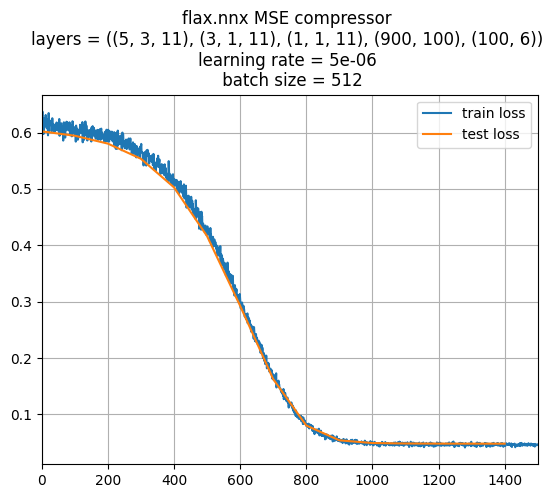

(66295, 6) (66295, 6)


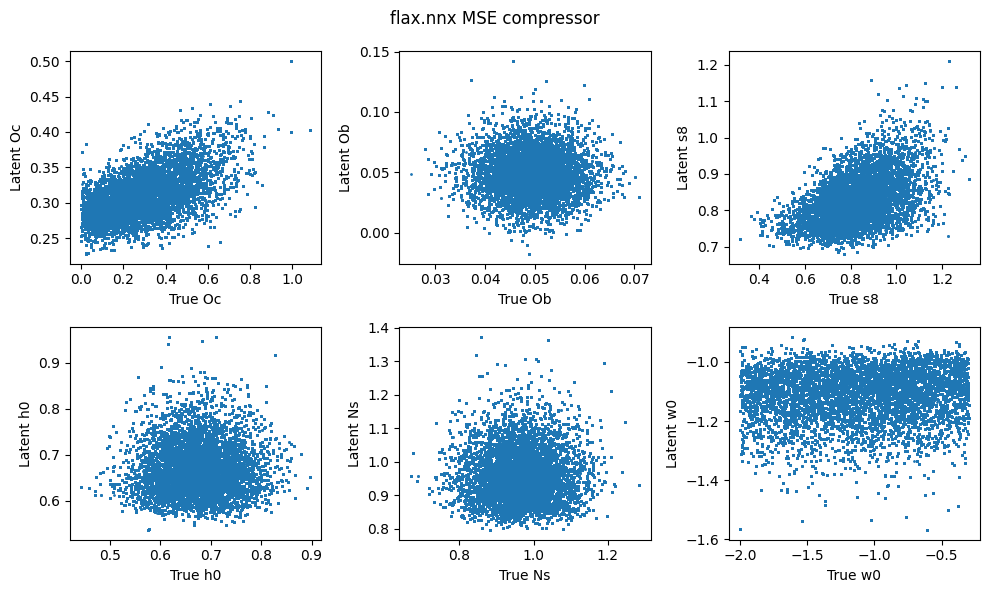

In [ ]:
# Training loss time series
fig, ax = plt.subplots()
ax.plot(range(STEPS), train_losses, label='train loss')
ax.plot(test_steps, test_losses, label='test loss')
ax.set_xlim(0,STEPS)
plt.grid()
plt.legend()
plt.title(f"flax.nnx MSE compressor \nlayers = {layer_dims} \nlearning rate = {LEARNING_RATE} \n batch size = {BATCH_SIZE}")
plt.savefig(f"nnx_MSE_loss_{STEPS}_steps.pdf")
plt.show()


# Truth vs Latent diagnostic scatter
gt = ground_truth = y
cd = compressed_data = CNN(x)
results = {
    "ground_truth": gt,
    "compressed_data": cd,
    "train_losses": train_losses,
    "test_losses": test_losses,
    "test_steps": test_steps
}
path = f"compressed_data/MSE_sbi_lens.pkl"
with open(path, 'wb') as f:
    pickle.dump(results, f)
print(compressed_data.shape, p.shape)

params = ['Oc','Ob','s8','h0','Ns','w0']
num_params = ground_truth.shape[1]

fig, axes = plt.subplots(2, 3, figsize=(10,6))
axes = axes.flatten()
for i in range(num_params):
    ax = axes[i]
    ax.scatter(gt[:,i], cd[:,i], s=1)
    ax.set_xlabel(f'True {params[i]}')
    ax.set_ylabel(f'Latent {params[i]}')

plt.suptitle("flax.nnx MSE compressor")
plt.tight_layout()
# plt.savefig(f"nnx_MSE_scatter_{STEPS}_steps.pdf")
plt.show()